##Import Dataset


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("KhoLinkSamSetCuaQan - KhoLinkSamSetCuaQan.csv")
df.shape

(9171, 2)

In [ ]:
df.head()


,Url,Labels
0,https://courses.ut.edu.vn/mod/quiz/attempt.php...,1
1,https://bruno.taweb.net.br/asd,0
2,https://claim-fantom-72h.com/FS24fvV243AQQ,0
3,https://m.ani4u.org/xem-anime/strawberry-panic...,1
4,https://ilovedevelopers.com/data/9NF28238VF7/i...,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9171 entries, 0 to 9170
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Url     9171 non-null   object
 1   Labels  9171 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 143.4+ KB


xử lý trùng

In [ ]:
#đếm số dòng trùng
print("Số dòng trùng nhau",df.duplicated().sum())

Số dòng trùng nhau 34


In [ ]:
#xóa dòng trùng
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9137 entries, 0 to 9170
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Url     9137 non-null   object
 1   Labels  9137 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 214.1+ KB


xử lý hàng bị null

In [ ]:
print(df.isnull().sum())

Url       0
Labels    0
dtype: int64


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9137 entries, 0 to 9170
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Url     9137 non-null   object
 1   Labels  9137 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 214.1+ KB


##Feature Extraction

In [ ]:
from tqdm import tqdm
import re #tìm kiếm trả về kiểu bool
from urllib.parse import urlparse
import math
from collections import Counter # Added this line

def calculate_entropy(s):
    if not s:
        return 0
    counts = Counter(s)
    total_length = len(s)
    entropy = 0
    for count in counts.values():
        probability = count / total_length
        entropy -= probability * math.log2(probability)
    return entropy

def extract_url_features(url):
    # Normalize and protect against NaN or non-string inputs
    if pd.isna(url):
        url = ""
    else:
        url = str(url)
    parsed = urlparse(url)
    hostname = parsed.hostname or ""

    ip_pattern = re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}\b')
    shorteners = ['bit.ly', 'tinyurl', 'goo.gl', 't.co', 'ow.ly', 'buff.ly']
    tlds = [".com", ".org", ".net", ".edu", ".gov", ".us", ".uk", ".ca", ".au", ".de",
            ".fr", ".it", ".es", ".nl", ".se", ".ch", ".jp", ".cn", ".kr", ".sg", ".hk",
            ".tw", ".in", ".br", ".mx", ".ru", ".pl", ".vn", ".id", ".th", ".my", ".ph", ".za"]

    features = {
        'qty_dot': url.count('.'),
        'qty_underline': url.count('_'),
        'ip_present': 1 if ip_pattern.search(url) else 0,
        'qty_and': url.count('&'),
        'qty_questionmark': url.count('?'),
        'path_length': len(parsed.path),
        'qty_equal': url.count('='),
        'qty_at': url.count('@'),
        'qty_digits': sum(c.isdigit() for c in url),
        'qty_hyphen': url.count('-'),
        'qty_plus': url.count('+'),
        'qty_asterisk': url.count('*'),
        'qty_slash': url.count('/'),
        'qty_dollar': url.count('$'),
        'url_length': len(url),
        'hostname_length': len(hostname),
        'shortener_present': 1 if any(s in hostname for s in shorteners) else 0,
        'qty_uppercase': sum(c.isupper() for c in url),
        'qty_exclamation': url.count('!'),
        'qty_space': url.count(' '),
        'qty_hastag': url.count('#'),
        'qty_tilde': url.count('~'),
        'qty_comma': url.count(','),
        'qty_percent': url.count('%'),
        'tld_present': 1 if any(t in url for t in tlds) else 0,
        'port_present': 1 if parsed.port else 0,
        'entropy': calculate_entropy(url)
    }
    return features

results = [extract_url_features(url) for url in tqdm(df['Url'].fillna(''))]
df_features = pd.DataFrame(results)
df_features['Label'] = df['Labels'].reset_index(drop=True)

df_features.head(350)

100%|██████████| 9137/9137 [00:00<00:00, 20189.18it/s]


,qty_dot,qty_underline,ip_present,qty_and,qty_questionmark,path_length,qty_equal,qty_at,qty_digits,qty_hyphen,...,qty_exclamation,qty_space,qty_hastag,qty_tilde,qty_comma,qty_percent,tld_present,port_present,entropy,Label
0,4,0,0,2,1,21,3,0,14,0,...,0,0,0,0,0,0,1,0,4.746852,1
1,3,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,1,0,3.831402,0
2,1,0,0,0,0,14,0,0,7,2,...,0,0,0,0,0,0,1,0,4.558519,0
3,5,5,1,0,1,27,1,0,30,5,...,0,0,0,0,0,0,1,0,5.747270,1
4,2,0,0,0,1,28,1,0,8,0,...,0,0,0,0,0,0,1,0,4.694465,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,1,0,0,0,0,5,0,0,0,0,...,0,0,0,0,0,0,1,0,3.784184,0
346,4,0,0,0,1,61,2,0,13,1,...,0,0,1,0,0,0,1,0,5.399595,1
347,1,0,0,0,0,1,0,0,0,2,...,0,0,0,0,0,0,1,0,4.018082,0
348,4,0,0,0,1,35,1,1,11,1,...,0,0,0,0,0,0,1,0,4.869767,0


Trực quan hóa

/tmp/ipython-input-863052780.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


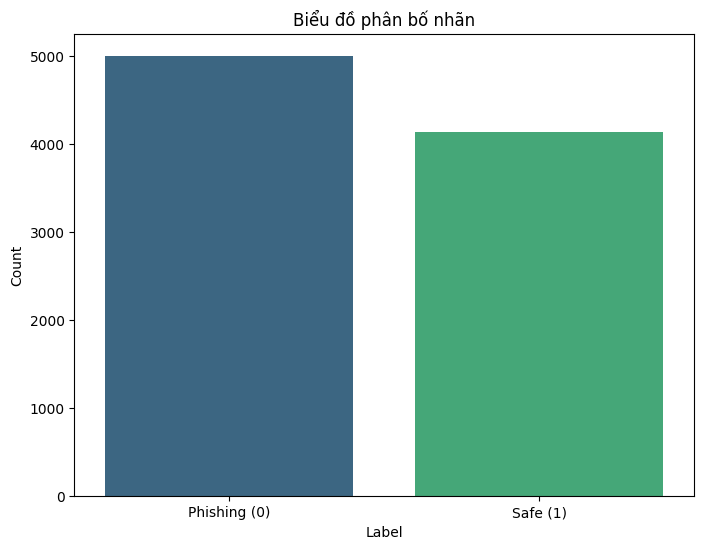

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts of each unique value in the 'Labels' column
label_counts = df['Labels'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Biểu đồ phân bố nhãn')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Phishing (0)', 'Safe (1)']) # Assuming 0 and 1 are the labels
plt.show()

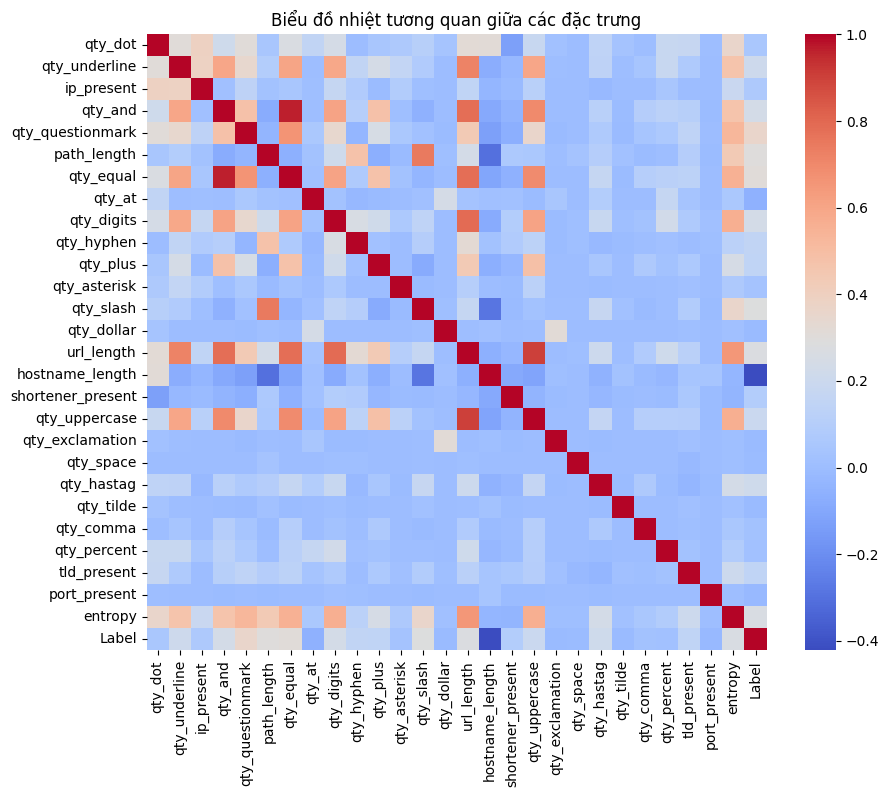

In [ ]:
# Tính ma trận tương quan
corr = df_features.corr()

# Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm') # annot=False cho đỡ rối mắt vì nhiều biến
plt.title("Biểu đồ nhiệt tương quan giữa các đặc trưng")
plt.show()

Text(0.5, 1.0, 'So sánh Entropy giữa URL An toàn và Độc hại')

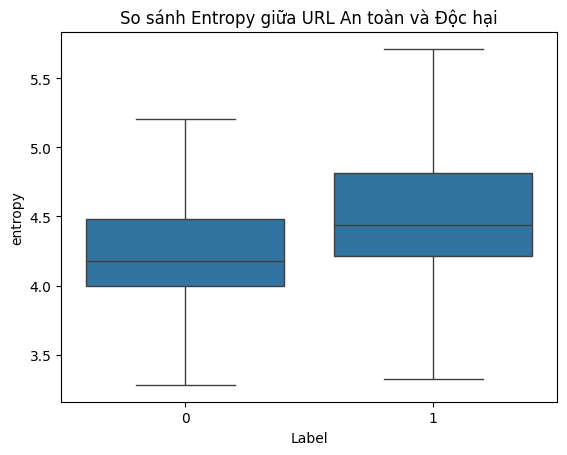

In [ ]:
sns.boxplot(data=df_features, x='Label', y='entropy', showfliers=False)
plt.title("So sánh Entropy giữa URL An toàn và Độc hại")

#Split train, test

In [ ]:
from sklearn.model_selection import train_test_split

X = df_features.drop(['Label'], axis=1)  #Lấy cột đặc trưng
Y = df_features['Label']  #Lấy cột nhãn

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (7309, 27)
X_test shape: (1828, 27)


##Chuẩn hóa đặc trưng

ví dụ: cột length_url giá trị tối đa là 80. cột nb_dots giá trị tối đa chỉ có 3 -> chênh lệch như vậy dẫn đến sai, chuyển về 1 đơn vị đo

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

#Chuẩn hóa và học trên dữ liệu train
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Train Machine Learning models

In [ ]:
from sklearn.ensemble import RandomForestClassifier
                                    #100 cây          chia cho đều   dùng cPU cho nó mạnh
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, Y_train)

score_rf = model_rf.score(X_train_scaled, Y_train)
print(f"Random Forest Accuracy: {score_rf}")

Random Forest Accuracy: 0.9975372828020249


##Đánh giá

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Kiểm tra, đánh giá trên tập test
Y_predict = model_rf.predict(X_test_scaled)

#Thông số hiệu suất
print(f"Accuracy: {accuracy_score(Y_test, Y_predict)}")
print(f"Precision: {precision_score(Y_test, Y_predict)}")
print(f"Recall: {recall_score(Y_test, Y_predict)}")
print(f"F1 Score: {f1_score(Y_test, Y_predict)}")

Accuracy: 0.9234135667396062
Precision: 0.9134502923976608
Recall: 0.922077922077922
F1 Score: 0.917743830787309


##Giao diện người dùng

In [ ]:
import gradio as gr
import numpy as np # Đảm bảo đã import numpy

def predict_url(url):
    if url.strip() == "":
        return "Please enter the URL"

    # 1. Lấy features (đang là dict)
    features_dict = extract_url_features(url)

    features_array = np.array([list(features_dict.values())])

    # 3. Scale dữ liệu
    features_scaled = scaler.transform(features_array)

    # Dự đoán
    probabilities = model_rf.predict_proba(features_scaled)[0]
    prob_phish = probabilities[0] * 100   #0 là Phishing
    prob_safe  = probabilities[1] * 100   #1 là Safe

    pred = model_rf.predict(features_scaled)[0]

    # Trả về kết quả
    if pred == 1:
        return f"SAFE\n\nSafety Score: {prob_safe:.2f}%"
    else:
        return f"PHISHING WARNING!\n\nDanger Score: {prob_phish:.2f}%"

ui = gr.Interface(
    fn=predict_url,
    inputs=gr.Textbox(
        label="Enter the URL to check",
        placeholder="https://example.com"
    ),
    outputs=gr.Textbox(label="Result"),
    title="🔍 Hệ thống kiểm tra URL an toàn",
    description="Nhập một liên kết bất kỳ để kiểm tra xem nó có an toàn hay không.",
)
ui.launch()

NameError: name 'gr' is not defined

## Huấn luyện mô hình học máy có giám sát: XGBoost Classifier

Chúng ta thực hiện phân tách tập dữ liệu đặc trưng đã trích xuất thành tập huấn luyện (80%) và tập kiểm thử (20%), sau đó huấn luyện mô hình phân loại **XGBoost Classifier** và đánh giá hiệu năng.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import numpy as np

# 1. Chuẩn bị dữ liệu đầu vào X và y
X = df_features.drop(columns=['Label'])
y = df_features['Label']

# 2. Phân chia tập dữ liệu huấn luyện và kiểm thử (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kích thước tập huấn luyện (X_train): {X_train.shape}")
print(f"Kích thước tập kiểm thử (X_test): {X_test.shape}")

# 3. Khởi tạo và huấn luyện mô hình XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# 4. Dự đoán và đánh giá kết quả
y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("\n=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: XGBOOST ===")
print(f"Độ chính xác (Accuracy): {xgb_accuracy * 100:.2f}%")
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_test, y_pred_xgb, target_names=['Phishing (0)', 'Safe (1)']))

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Trực quan hóa Confusion Matrix cho XGBoost
plt.figure(figsize=(8, 6))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Phishing', 'Safe'])
disp_xgb.plot(cmap='Blues', values_format='d')
plt.title(f'XGBoost Confusion Matrix (Accuracy: {xgb_accuracy*100:.2f}%)')
plt.show()